In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from matplotlib.colors import LinearSegmentedColormap
import shap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Ellipse



Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:

# ML models
from openxai.LoadModel import LoadModel

# Data loaders
from openxai.dataloader import return_loaders

# Explanation models
from openxai.Explainer import Explainer

# Evaluation methods
from openxai.evaluator import Evaluator

In [3]:
prefix = '../DATA/EXPLAINER_OUTPUTS/META/'
# data_name = 'german'  # shap and lime @ 0, ig 0.3 rot 1.hhh 
data_name = 'compas'  # acceptable baselines (all ~1.hhh)
# data_name = 'heloc'  # shap and lime @ 0.55, others ~0.hhh
# data_name = 'adult'  # shap and lime @ 2.5, ig -1, rot -0.7
model_name = 'lr'
explainers = ['shap', 'lime', 'ig', 'rot']

explanation_dfs = []
baseline_dfs = []

In [4]:
model = LoadModel(data_name=data_name, ml_model=model_name, pretrained=True)

# Get training and test loaders
loader_train, loader_test = return_loaders(data_name=data_name, download=True, batch_size=1)


data_all = torch.FloatTensor(loader_train.dataset.data)#[:51,:]

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [5]:
y_preds = model(data_all).detach().numpy()[:,1].flatten()


In [6]:
for explainer in explainers:
    df = pd.read_csv(f'{prefix}exp_{data_name}_{model_name}_{explainer}.csv')
    df = df.drop(columns='Unnamed: 0')
    explanation_dfs.append(df)
    df = pd.read_csv(f'{prefix}base_{data_name}_{model_name}_{explainer}.csv')
    df = df.drop(columns='Unnamed: 0')
    baseline_dfs.append(df)


In [7]:
df = pd.DataFrame({'model_proba': model(data_all).detach().numpy()[:,1]})
logit_tensor = model.linear(data_all).detach().numpy()
df['model_logits'] = logit_tensor[:,1] - logit_tensor[:,0]
for exp_df, base_df, explainer in zip(explanation_dfs, baseline_dfs, ['shap', 'lime', 'ig', 'rot']):
    print(f'{explainer} baseline : {np.mean(base_df)}')
    imp_sums = exp_df.sum(axis=1).values.flatten() + base_df.values.flatten()
    df[f'{explainer}_pred'] = imp_sums
    pass
exps = explanation_dfs[0]
baseline = baseline_dfs[0]

shap baseline : 1.0269299
lime baseline : 1.0278198125987443
ig baseline : 1.2375457999999997
rot baseline : 1.0847219000000001


In [8]:
df_sorted = df.sort_values(by='model_logits')


In [9]:
neg_indices = df[df['model_proba'] <= 0.5].index
pos_indices = df[df['model_proba'] > 0.5].index


In [10]:
neg_indices = df[(df['model_proba'] <= 0.5) & (df['model_logits']<=0) & (df['shap_pred']<=0) & (df['rot_pred']<=0)].index
pos_indices = df[(df['model_proba'] > 0.5) & (df['model_logits'] > 0) & (df['shap_pred'] > 0) & (df['rot_pred'] > 0)].index


In [11]:
all_df = loader_train.dataset.X
neg_df = all_df.loc[neg_indices]
pos_df = all_df.loc[pos_indices]
f_datapoints = neg_df.copy()


In [12]:
def select_row(datapoint, df, priority, l0_thresh=2, l1_thresh=4):
    """
    datapoint: 1D array-like (same length as df columns)
    df: pandas DataFrame
    priority: pandas Series (same index as df)
    l0_thresh: max number of mismatched features allowed
    l1_thresh: minimum L1 distance required
    """

    # Ensure arrays
    x = np.array(datapoint)
    X = df.values

    # L0 distance: number of features that differ
    l0_dist = np.sum(X != x, axis=1)

    # L1 distance: sum of absolute differences
    l1_dist = np.sum(np.abs(X - x), axis=1)

    # Mask: low L0 and high L1
    mask = (l0_dist <= l0_thresh) & (l1_dist >= l1_thresh)

    # If no valid rows, return None
    if not mask.any():
        return None

    # Subset + sort by priority
    candidates = priority[mask].sort_values(ascending=False)

    # Return index of highest-priority candidate
    return candidates.index[0]


In [13]:
cf_indices = []

for fact_row in f_datapoints.values:
    cf_indices.append(select_row(fact_row, pos_df, df.loc[pos_indices]['model_logits']))


In [14]:


cf_datapoints = pos_df.loc[cf_indices].copy()


In [15]:
f_shap = explanation_dfs[0].loc[f_datapoints.index]
cf_shap = explanation_dfs[0].loc[cf_datapoints.index]

f_lime = explanation_dfs[1].loc[f_datapoints.index]
cf_lime = explanation_dfs[1].loc[cf_datapoints.index]

f_ig = explanation_dfs[2].loc[f_datapoints.index]
cf_ig = explanation_dfs[2].loc[cf_datapoints.index]

f_rot = explanation_dfs[3].loc[f_datapoints.index]
cf_rot = explanation_dfs[3].loc[cf_datapoints.index]

In [16]:
b_f_shap = baseline_dfs[0].loc[f_datapoints.index]
b_cf_shap = baseline_dfs[0].loc[cf_datapoints.index]

b_f_lime = baseline_dfs[1].loc[f_datapoints.index]
b_cf_lime = baseline_dfs[1].loc[cf_datapoints.index]

b_f_ig = baseline_dfs[2].loc[f_datapoints.index]
b_cf_ig = baseline_dfs[2].loc[cf_datapoints.index]

b_f_rot = baseline_dfs[3].loc[f_datapoints.index]
b_cf_rot = baseline_dfs[3].loc[cf_datapoints.index]

In [17]:

def plot_multi_decision(shap_imps, lime_imps, ig_imps, rot_imps,
                        shap_base, lime_base, ig_base, rot_base,
                        feature_names, explicand, plot_title, ydatapoint):
    """
    Plot 4 decision plots for a single datapoint using SHAP values.

    Parameters
    ----------
    shap_val1, shap_val2, shap_val3, shap_val4 : array-like, shape (n_features,)
        SHAP values for each method.
    base1, base2, base3, base4 : float
        Base values (expected values) for each method.
    feature_names : list of str
        Names of the features.
    feature_values_row : array-like, shape (n_features,)
        Feature values of the datapoint (same repeated for all 4 methods).
    """
    plt.clf()
    ig_base = 0.1
    lime_base=-0.1
    plot_title = '(logit) baseline'
    shap_val1, shap_val2, shap_val3, shap_val4 = ig_imps, lime_imps, shap_imps, rot_imps
    base1, base2, base3, base4 = ig_base, lime_base, shap_base, rot_base
    feature_values_row = explicand

    shap_values = np.array([shap_val1, shap_val2, shap_val3, shap_val4])
    base_values = [float(base1), float(base2), float(base3), float(base4)]

    # Repeating the feature row for each explanation
    feature_values = np.tile(np.array(feature_values_row), (4, 1))

    explanation_cmaps = [
        LinearSegmentedColormap.from_list("const_blue",   ["C3", "C3"]),
        LinearSegmentedColormap.from_list("const_orange", ["C2", "C2"]),
        LinearSegmentedColormap.from_list("const_green",  ["C1", "C1"]),
        LinearSegmentedColormap.from_list("const_red",    ["C0", "C0"]),
    ]

    alpha_values = [0.8, 0.8, 0.8, 1.0]
    legend_labels = ["Grad*", "LIME", "SHAP", "RoT"]

    # plot_title = "Decision Plots for A Single Datapoint"
    x_axis_label = "(logit) baseline + $\Sigma$ importances"

    # plt.figure()
    fig, ax = plt.subplots(figsize=(8,5))
    print(fig.get_size_inches())
    handles = []
    _xmin = 1000000
    _xmax = -1000000

    for i in range(len(shap_values)):
        highlight_this = i == 3
        # highlight_this = False
        linestyle = '--' if highlight_this else '-'

        shap.plots.decision(
            base_value=base_values[i],
            shap_values=shap_values[i:i+1],
            features=None,  # not needed since feature_names used
            # feature_names=[f'{nm}\n={vl}' for nm, vl in zip(list(feature_names), list(explicand))],
            feature_names=[f'{nm}' for nm, vl in zip(list(feature_names), list(explicand))],
            feature_order=[2,5,1,4,6,3,0],#[i for i in range(len(feature_names))],#'importance',
            feature_display_range=slice(None),
            plot_color=explanation_cmaps[i],
            alpha=alpha_values[i],
            color_bar=False,
            auto_size_plot=False,
            title=None,
            show=False,
            return_objects=True,
            highlight=0 if highlight_this else None,
            # link='logit'
            link='identity'
        )
        _xlims = ax.get_xlim()
        if min(_xlims) < _xmin:
            _xmin = min(_xlims)
        if max(_xlims) > _xmax:
            _xmax = max(_xlims)

        # Create legend handle
        handles.append(Line2D([0], [0],
                              color=plt.get_cmap(explanation_cmaps[i])(0.8),
                              linestyle=linestyle, linewidth=3,
                              alpha=alpha_values[i]))

    # Remove vertical grey base_value lines
    for line in ax.lines[:]:
        xdata = line.get_xdata()
        if np.allclose(xdata, xdata[0]):  # vertical line (all x are same)
            line.remove()

    # Final formatting
    plt.title(plot_title, fontsize=14)
    plt.xlabel(x_axis_label, fontsize=14)
    plt.ylabel(ydatapoint, fontsize=14)
    plt.legend(handles[::-1], legend_labels[::-1], loc='best', fontsize=12)
    # plt.xlim((_xmin, _xmax))
    plt.xlim((-6.5, 4))
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=13)
    plt.grid(False)
    plt.axvline(0, linestyle=':', color='gray', alpha=0.6, zorder=-1)
    
    # ax.axhspan(5, 7, facecolor='gray', alpha=0.2, clip_on=False, zorder=-1)
    rect = Rectangle(
        (-10.5, 5),   # extend left beyond the axis (negative x in data units)
        width=14.5,    # big enough width
        height=2,    # covers 5–7
        # facecolor="lightgray",
        # alpha=0.5,
        facecolor="gray",
        alpha=0.15,
        transform=ax.transData,   # use data coords for y, data for x
        clip_on=False,            # allow outside the axis
        zorder=-2,
        # hatch='oo',
        # hatch_color='lightgrey'
    )
    ax.add_patch(rect)
    
    plt.tight_layout()
    

In [18]:
fact_features = ['$age$:   $\mathbf{30}$', 'two yr recid.:     1', 'priors count:     13', '$length$ $of$ $stay$: $\mathbf{474}$', 'charge degree:     1', 'sex:     0', 'race:    1']
counterfact_features = ['$age$:    $\mathbf{64}$', 'two yr recid.:     1', 'priors count:     13', '$length$ $of$ $stay$:     $\mathbf{1}$', 'charge degree:   1', 'sex:     0', 'race:    1']

fact_features = [
    '$age$:    $\mathbf{30}$', 
    'two yr recid.:       1', 
    'priors count:     13', 
    '$length$ $of$ $stay$:  $\mathbf{474}$', 
    'charge degree:       1', 
    'sex:       0', 
    'race:       1',
]
counterfact_features = [
    '$age$:   $\mathbf{64}$', 
    'two yr recid.:      1', 
    'priors count:    13', 
    '$length$ $of$ $stay$:      $\mathbf{1}$', 
    'charge degree:      1', 
    'sex:      0', 
    'race:      1',
]


fact_features = [
    '$age$: $\mathbf{30}$', 
    'two yr\nrecid.: 1', 
    'priors\ncount: 13', 
    '$length$ $of$\n$stay$: $\mathbf{474}$', 
    'charge\ndegree: 1', 
    'sex: 0', 
    'race: 1',
]

counterfact_features = [
    '$age$: $\mathbf{64}$', 
    'two yr\nrecid.: 1', 
    'priors\ncount: 13', 
    '$length$ $of$\n$stay$: $\mathbf{1}$', 
    'charge\ndegree: 1', 
    'sex: 0', 
    'race: 1',
]


both_features = [
    '$age$\n$X_p: \mathbf{64}$\n$X_n: \mathbf{30}$', 
    'two yr recid.\n$X_p$: 1\n$X_n$: 1', 
    'priors count\n$X_p$: 13\n$X_n$: 13', 
    '$length$ $of$ $stay$\n$X_p: \mathbf{1}$\n$X_n: \mathbf{474}$', 
    'charge degree\n$X_p$: 1\n$X_n$: 1', 
    'sex\n$X_p$: 0\n$X_n$: 0', 
    'race\n$X_p$: 1\n$X_n$: 1',
]

both_features = [
    '$age$\ninitial: $\mathbf{64}$           \nfinal:   $\mathbf{30}$           ', 
    'two yr recid.\n1\n1', 
    'priors count\n13\n13', 
    # '$length$ $of$ $stay$\ninitial :      $\mathbf{1}$\nfinal   : $\mathbf{474}$', 
    '$length$ $of$ $stay$\n$\mathbf{1}$\n$\mathbf{474}$', 
    'charge degree\n1\n1', 
    'sex\n0\n0', 
    'race\n1\n1',
]





In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_bars(
    feature_names,   # list of 7 strings
    heights_list,    # list of 4 lists, each length 7
    category_labels, # list of 4 strings
    colors,          # list of 4 colors
    hatch=None,
    ax = None,
    fill = True,
):
    """
    Plots a grouped bar plot with 7 features and 4 categories.

    Parameters
    ----------
    feature_names : list of str
        Names of the 7 features (x-axis).
    heights_list : list of lists
        Each list contains 7 heights (floats/ints). Should be length 4 (for 4 categories).
    category_labels : list of str
        Labels for the 4 categories.
    colors : list of str
        Colors for the 4 categories (any valid matplotlib color).
    """
    if ax is None:
        plt.figure(figsize=(10,5))
        ax = plt.gca()
    feature_names = [feature_names[0], feature_names[3], feature_names[2], feature_names[5], feature_names[1], feature_names[6], feature_names[4]]
    new_heights = []
    for height in heights_list:
        new_heights.append([height[0], height[3], height[2], height[5], height[1], height[6], height[4]])
    heights_list = new_heights
    n_features = len(feature_names)
    n_categories = len(heights_list)
    
    x = np.arange(n_features)  # positions for features
    bar_width = 0.2            # width of each bar


    for i in range(n_categories):
        if fill:
            ax.bar(
                x + i*bar_width + 0.05,
                # x + i*bar_width + 0.035,
                heights_list[i],
                # width=bar_width-0.03 - 0.1,
                width=bar_width-0.03 - 0.1,
                label=category_labels[i],
                color=colors[i],
                edgecolor=colors[i],
                linestyle='-',
                alpha=1.0,
                hatch='\\',
                fill=True
            )
        else:
            ax.bar(
                x + i*bar_width - 0.05,
                # x + i*bar_width - 0.035,
                heights_list[i],
                # width=bar_width-0.02 - 0.1,
                width=bar_width-0.02 - 0.1,
                label=category_labels[i],
                color=colors[i],
                edgecolor=colors[i],
                linestyle='-',
                alpha=1.0,
                hatch='//',
                fill=False
            )
            pass

    ax.set_xticks(x + (n_categories-1)*bar_width/2)
    ax.set_xticklabels(feature_names, rotation=0, ha="center", fontsize=12)
    ax.set_ylabel("Feature Importance", fontsize=14)
    ax.set_xlabel('Feature Value', fontsize=14)
    # ax.legend()
    ax.set_title("")
    ax.set_ylim((-4,4))

    plt.tight_layout()
    return ax
    # plt.show()


In [20]:
# clean_count = 0
# dirty_count = 0
magic_row_number = -1
for row_number in range(len(f_datapoints)):
    if f_datapoints.iloc[row_number]['age'] == 30:
        if f_datapoints.iloc[row_number]['length_of_stay'] == 474:
            print(row_number)
            print(f_datapoints.iloc[row_number])
            print(cf_datapoints.iloc[row_number])
            print()
            magic_row_number = row_number
            break

for row_number in range(len(f_datapoints)):            
    if row_number != magic_row_number: ## != 55:
        continue

    fact_row = f_datapoints.iloc[row_number]
    counterfact_row = cf_datapoints.iloc[row_number]
    manhattan_distance = np.sum(np.abs(np.array(fact_row) - np.array(counterfact_row)))

    
    shap_imps_f = f_shap.iloc[row_number]
    shap_imps_cf = cf_shap.iloc[row_number]
    lime_imps_f = f_lime.iloc[row_number]
    lime_imps_cf = cf_lime.iloc[row_number]
    ig_imps_f = f_ig.iloc[row_number]
    ig_imps_cf = cf_ig.iloc[row_number]
    rot_imps_f = f_rot.iloc[row_number]
    rot_imps_cf = cf_rot.iloc[row_number]
    
    shap_b_f = b_f_shap.iloc[row_number]
    lime_b_f = b_f_lime.iloc[row_number]
    ig_b_f = b_f_ig.iloc[row_number]
    rot_b_f = b_f_rot.iloc[row_number]
    shap_b_cf = b_cf_shap.iloc[row_number]
    lime_b_cf = b_cf_lime.iloc[row_number]
    ig_b_cf = b_cf_ig.iloc[row_number]
    rot_b_cf = b_cf_rot.iloc[row_number]

    shap_f_pred = np.sum(shap_imps_f) + float(shap_b_f)
    rot_f_pred = np.sum(rot_imps_f) + float(rot_b_f)
    shap_cf_pred = np.sum(shap_imps_cf) + float(shap_b_cf)
    rot_cf_pred = np.sum(rot_imps_cf) + float(rot_b_cf)


48
age                   30
two_year_recid         1
priors_count          13
length_of_stay       474
c_charge_degree_F      1
sex_Female             0
race                   1
Name: 1339, dtype: int64
age                  64
two_year_recid        1
priors_count         13
length_of_stay        1
c_charge_degree_F     1
sex_Female            0
race                  1
Name: 299, dtype: int64



Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


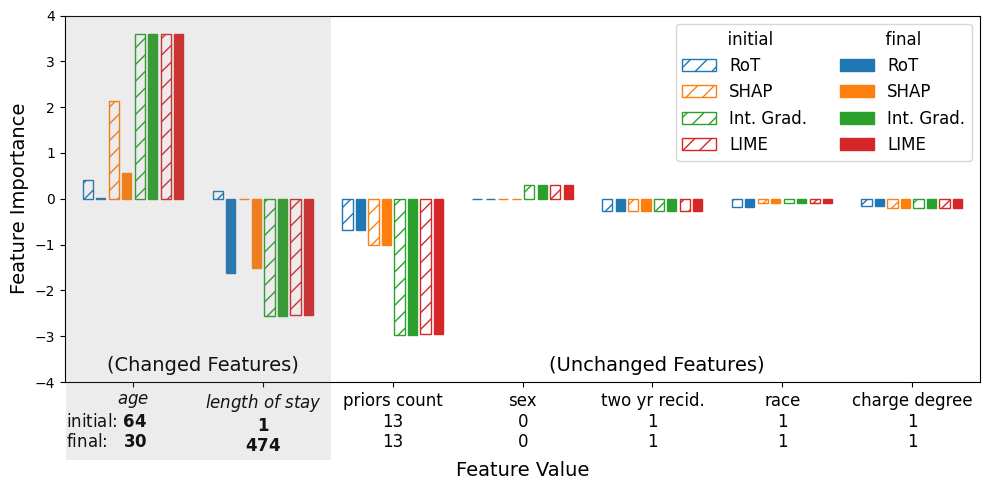

In [21]:
ax = plot_grouped_bars(fact_features, [rot_imps_f, shap_imps_f, ig_imps_f, lime_imps_f], ['RoT', 'SHAP', 'Int. Grad.', 'LIME'], ['C0', 'C1', 'C2', 'C3'], hatch=None)

plot_grouped_bars(both_features, [rot_imps_cf, shap_imps_cf, ig_imps_cf, lime_imps_cf], ['RoT', 'SHAP', 'Int. Grad.', 'LIME'], ['C0', 'C1', 'C2', 'C3'], hatch=None, ax=ax, fill=False)

plt.text(0.1, -3.75, '(Changed Features)', fontsize=14, color='black')
plt.text(3.5, -3.75, '(Unchanged Features)', fontsize=14, color='black')

_xlims = ax.get_xlim()
ax.set_xlim((_xlims[0]+0.2, _xlims[1]-0.2))
# plt.axvspan(-0.21,1.81, color='gray', alpha=0.15)

# Rectangle in data coordinates, but drawn over everything
rect = Rectangle(
    (-0.22, -5.7), 2.04, 9.7,     # x, y, width, height
    facecolor='gray',
    alpha=0.15,
    clip_on=False,            # allows it to extend beyond plot area
    zorder=10                 # draw on top
)
ax.add_patch(rect)

# plt.axhline(0, color='gray', linestyle=':', alpha=0.5, zorder=-1)


h, l = ax.get_legend_handles_labels()
ph = [plt.plot([],marker="", ls="")[0]]*2
handles = ph[1:] + h[4:] + ph[:1] + h[:4]
# labels = ["initial datapoint\n(positive prediction)"] + l[4:] + ["final datapoint\n(negative prediction)"] + l[:4]
labels = ["      initial"] + l[4:] + ["      final"] + l[:4]
leg = plt.legend(handles, labels, ncol=2, fontsize=12)


for vpack in leg._legend_handle_box.get_children():
    for hpack in vpack.get_children()[:1]:
        hpack.get_children()[0].set_width(0)

plt.savefig('../PLOTS/OpenXAI_COMPAS_bars.pdf', dpi=300)

# plt.legend(ncols=2)


In [22]:
print(fact_row)
print(counterfact_row)

age                   30
two_year_recid         1
priors_count          13
length_of_stay       474
c_charge_degree_F      1
sex_Female             0
race                   1
Name: 1339, dtype: int64
age                  64
two_year_recid        1
priors_count         13
length_of_stay        1
c_charge_degree_F     1
sex_Female            0
race                  1
Name: 299, dtype: int64
